In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, r2_score


In [82]:
df=pd.read_csv("CarPrice_Assignment.csv")
# Strip whitespace from column names so columns like ' carheight ' become 'carheight'
df.columns = df.columns.str.strip()
df.head(10)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.000
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.000
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.000
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.000
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.000
5,6,2,audi fox,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250.000
6,7,1,audi 100ls,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710.000
7,8,1,audi 5000,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920.000
8,9,1,audi 4000,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875.000
9,10,0,audi 5000s (diesel),gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,17859.167


In [83]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [85]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [86]:
df.shape

(205, 26)

In [87]:
df[df.duplicated()]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


There is no duplicates

In [88]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

There is no null values

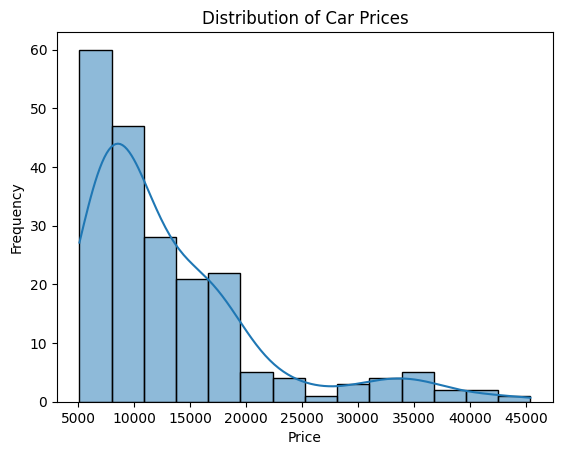

In [89]:
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

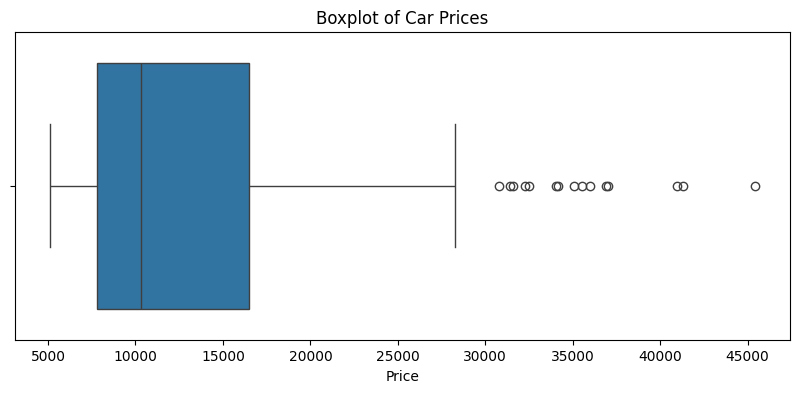

In [90]:
plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Car Prices')
plt.xlabel('Price')
plt.show()


In [91]:
q1,q2,q3 = np.percentile(df['price'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['price']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

7788.0 10295.0 16503.0
IQR = 8715.0
Lower Limit -5284.5
Upper Limit 29575.5
[30760.0, 41315.0, 36880.0, 32250.0, 35550.0, 36000.0, 31600.0, 34184.0, 35056.0, 40960.0, 45400.0, 32528.0, 34028.0, 37028.0, 31400.5]


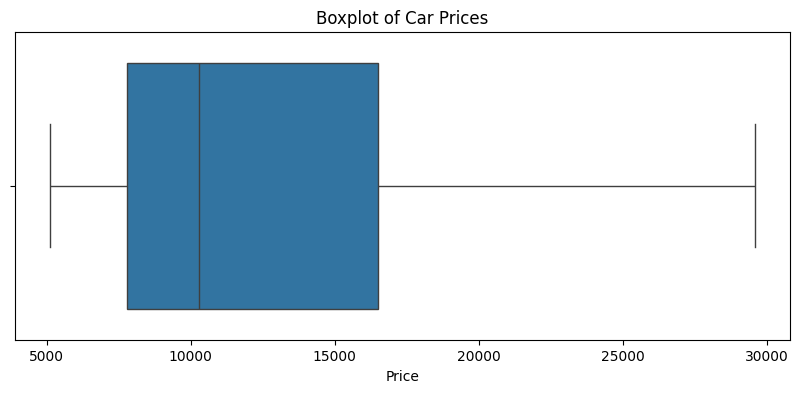

In [92]:
df['price']=np.where(df['price']>upper_limit,upper_limit,df['price'])
df['price']=np.where(df['price']<lower_limit,lower_limit,df['price'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Car Prices')
plt.xlabel('Price')
plt.show()
                     

In [93]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [94]:
df.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

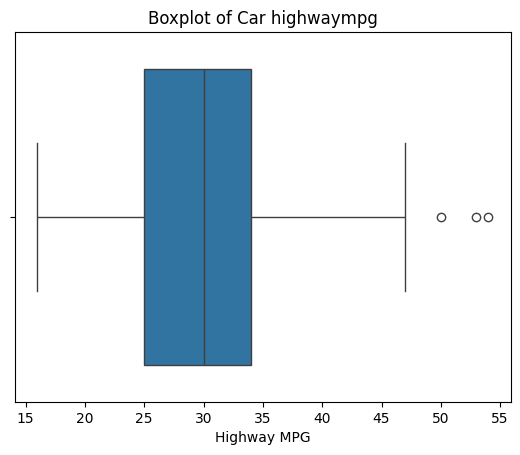

In [95]:
sns.boxplot(x=df['highwaympg'])
plt.title('Boxplot of Car highwaympg')
plt.xlabel('Highway MPG')
plt.show()

25.0 30.0 34.0
IQR = 9.0
Lower Limit 11.5
Upper Limit 47.5
[53, 54, 50]


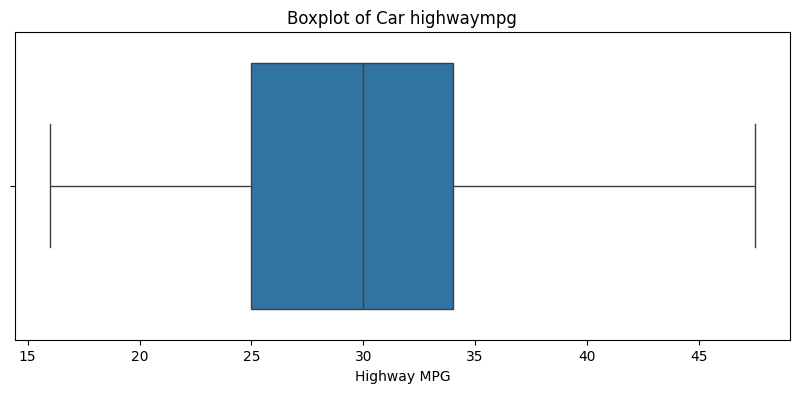

In [96]:
q1,q2,q3 = np.percentile(df['highwaympg'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['highwaympg']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['highwaympg']=np.where(df['highwaympg']>upper_limit,upper_limit,df['highwaympg'])
df['highwaympg']=np.where(df['highwaympg']<lower_limit,lower_limit,df['highwaympg'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['highwaympg'])
plt.title('Boxplot of Car highwaympg')
plt.xlabel('Highway MPG')
plt.show()

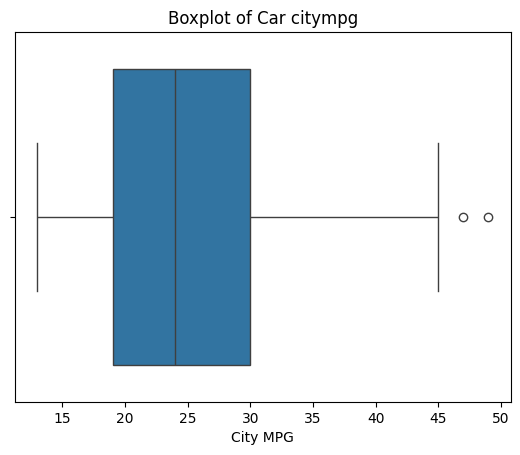

In [97]:
sns.boxplot(x=df['citympg'])
plt.title('Boxplot of Car citympg')
plt.xlabel('City MPG')
plt.show()

19.0 24.0 30.0
IQR = 11.0
Lower Limit 2.5
Upper Limit 46.5
[47, 49]


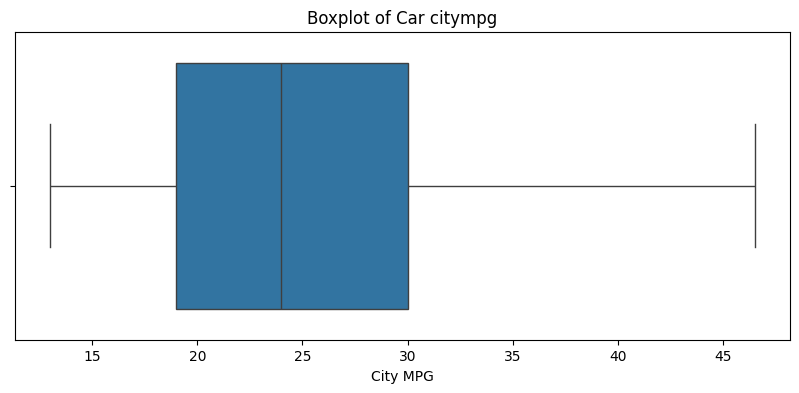

In [98]:
q1,q2,q3 = np.percentile(df['citympg'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['citympg']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['citympg']=np.where(df['citympg']>upper_limit,upper_limit,df['citympg'])
df['citympg']=np.where(df['citympg']<lower_limit,lower_limit,df['citympg'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['citympg'])
plt.title('Boxplot of Car citympg')
plt.xlabel('City MPG')
plt.show()

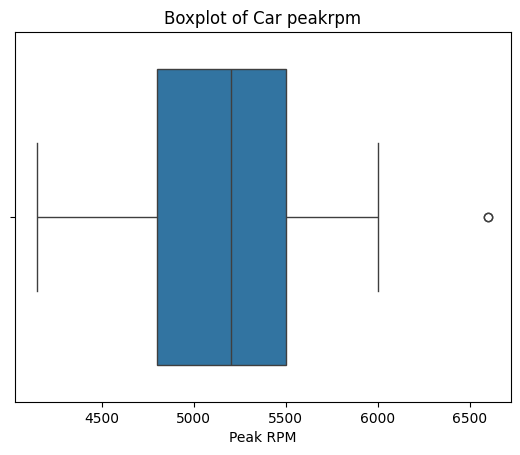

In [99]:
sns.boxplot(x=df['peakrpm'])
plt.title('Boxplot of Car peakrpm')
plt.xlabel('Peak RPM')
plt.show()

4800.0 5200.0 5500.0
IQR = 700.0
Lower Limit 3750.0
Upper Limit 6550.0
[6600, 6600]


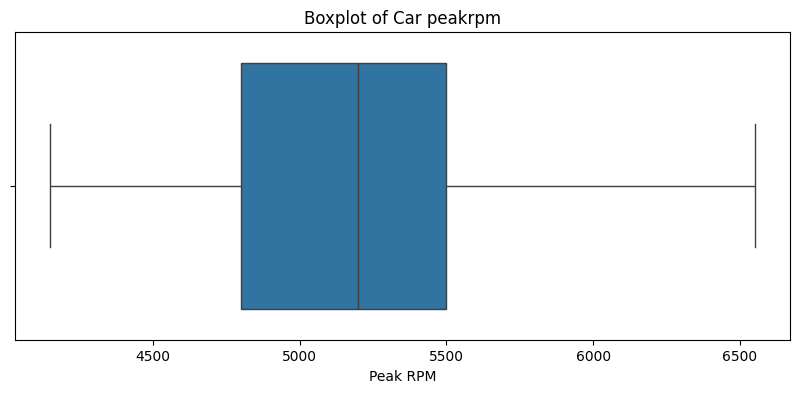

In [100]:
q1,q2,q3 = np.percentile(df['peakrpm'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['peakrpm']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['peakrpm']=np.where(df['peakrpm']>upper_limit,upper_limit,df['peakrpm'])
df['peakrpm']=np.where(df['peakrpm']<lower_limit,lower_limit,df['peakrpm'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['peakrpm'])
plt.title('Boxplot of Car peakrpm')
plt.xlabel('Peak RPM')
plt.show()

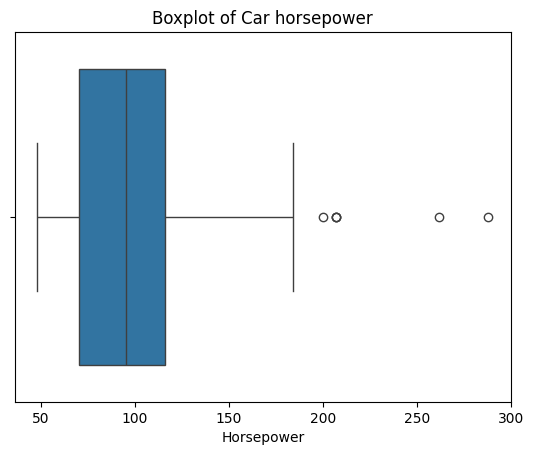

In [101]:
sns.boxplot(x=df['horsepower'])
plt.title('Boxplot of Car horsepower')
plt.xlabel('Horsepower')
plt.show()

70.0 95.0 116.0
IQR = 46.0
Lower Limit 1.0
Upper Limit 185.0
[262, 200, 207, 207, 207, 288]


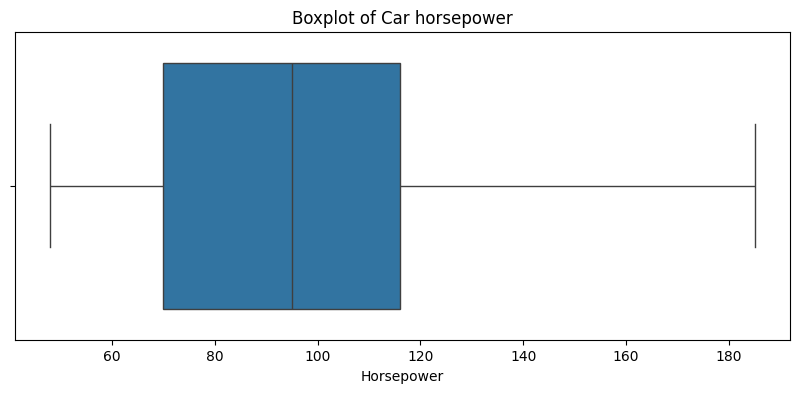

In [102]:
q1,q2,q3 = np.percentile(df['horsepower'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['horsepower']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['horsepower']=np.where(df['horsepower']>upper_limit,upper_limit,df['horsepower'])
df['horsepower']=np.where(df['horsepower']<lower_limit,lower_limit,df['horsepower'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['horsepower'])
plt.title('Boxplot of Car horsepower')
plt.xlabel('Horsepower')
plt.show()

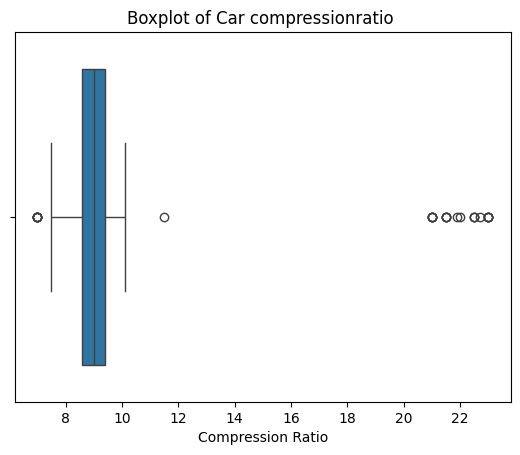

In [103]:
sns.boxplot(x=df['compressionratio'])
plt.title('Boxplot of Car compressionratio ')
plt.xlabel('Compression Ratio')
plt.show()

8.6 9.0 9.4
IQR = 0.8000000000000007
Lower Limit 7.399999999999999
Upper Limit 10.600000000000001
[7.0, 7.0, 11.5, 22.7, 22.0, 21.5, 21.5, 21.5, 21.5, 7.0, 7.0, 7.0, 21.9, 21.0, 21.0, 21.0, 21.0, 21.0, 7.0, 7.0, 22.5, 22.5, 22.5, 23.0, 23.0, 23.0, 23.0, 23.0]


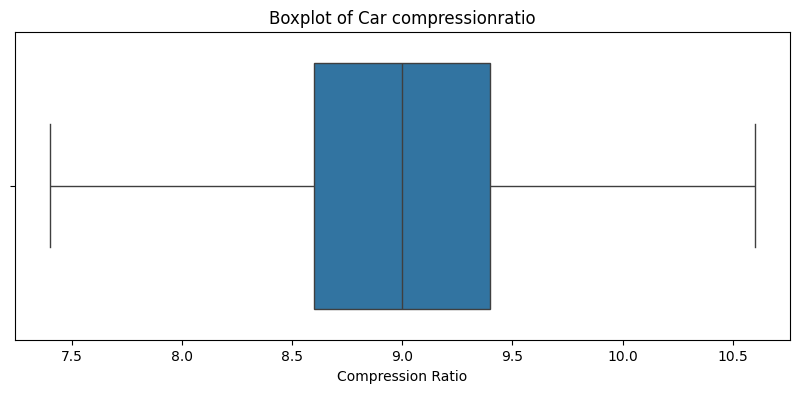

In [104]:
q1,q2,q3 = np.percentile(df['compressionratio'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['compressionratio']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['compressionratio']=np.where(df['compressionratio']>upper_limit,upper_limit,df['compressionratio'])
df['compressionratio']=np.where(df['compressionratio']<lower_limit,lower_limit,df['compressionratio'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['compressionratio'])
plt.title('Boxplot of Car compressionratio')
plt.xlabel('Compression Ratio')
plt.show()

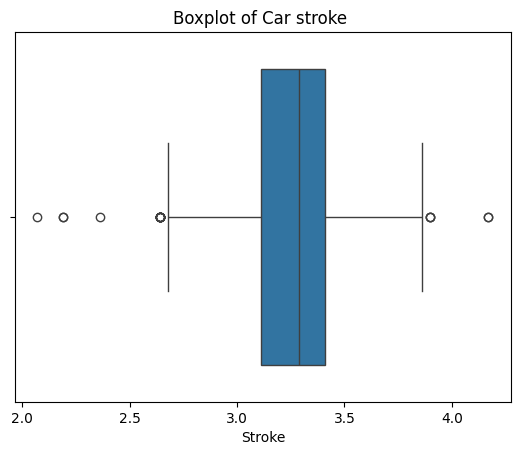

In [105]:
sns.boxplot(x=df['stroke'])
plt.title('Boxplot of Car stroke ')
plt.xlabel('Stroke')
plt.show()

3.11 3.29 3.41
IQR = 0.30000000000000027
Lower Limit 2.6599999999999993
Upper Limit 3.8600000000000003
[3.9, 4.17, 4.17, 2.19, 2.19, 3.9, 3.9, 2.07, 2.36, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64, 2.64]


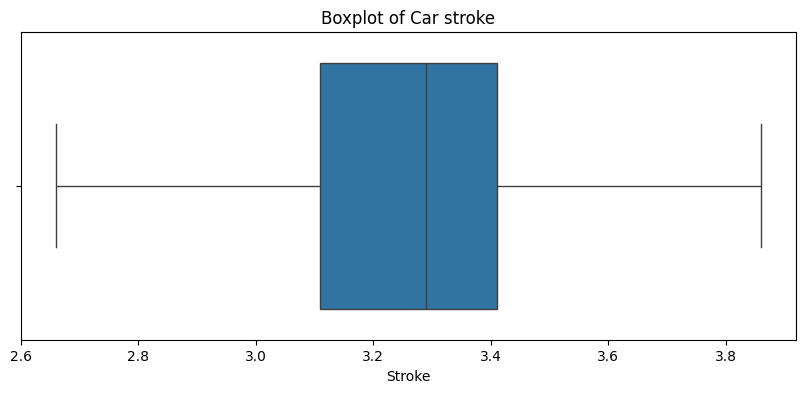

In [106]:
q1,q2,q3 = np.percentile(df['stroke'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['stroke']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['stroke']=np.where(df['stroke']>upper_limit,upper_limit,df['stroke'])
df['stroke']=np.where(df['stroke']<lower_limit,lower_limit,df['stroke'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['stroke'])
plt.title('Boxplot of Car stroke')
plt.xlabel('Stroke')
plt.show()

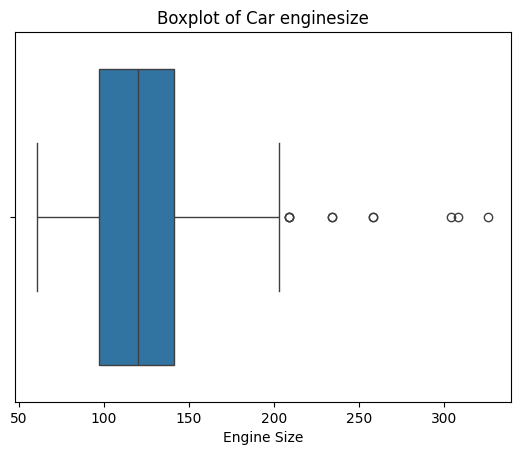

In [107]:
sns.boxplot(x=df['enginesize'])
plt.title('Boxplot of Car enginesize')
plt.xlabel('Engine Size')
plt.show()

97.0 120.0 141.0
IQR = 44.0
Lower Limit 31.0
Upper Limit 207.0
[209, 209, 209, 258, 258, 326, 234, 234, 308, 304]


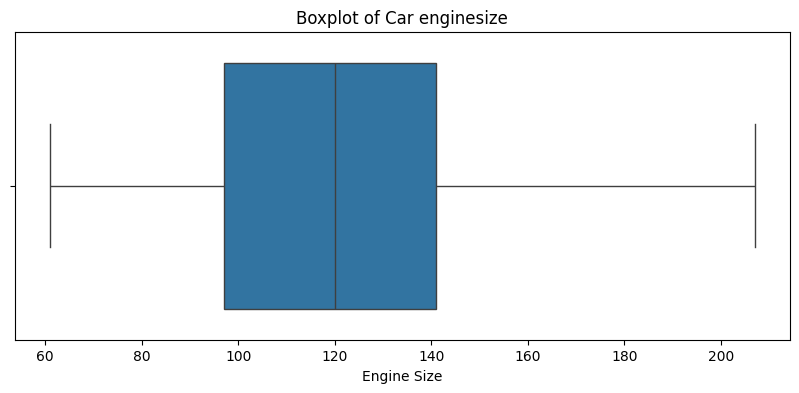

In [108]:
q1,q2,q3 = np.percentile(df['enginesize'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['enginesize']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['enginesize']=np.where(df['enginesize']>upper_limit,upper_limit,df['enginesize'])
df['enginesize']=np.where(df['enginesize']<lower_limit,lower_limit,df['enginesize'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['enginesize'])
plt.title('Boxplot of Car enginesize')
plt.xlabel('Engine Size')
plt.show()

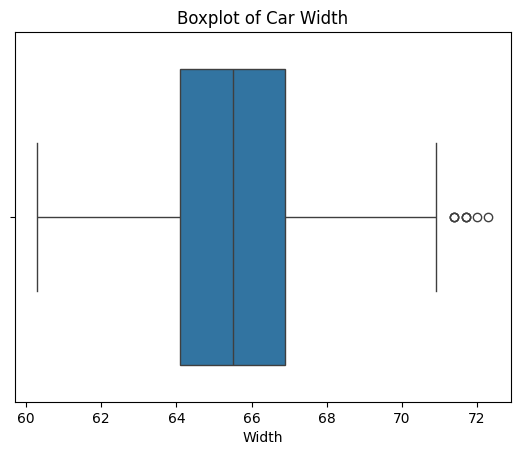

In [109]:
sns.boxplot(x=df['carwidth'])
plt.title('Boxplot of Car Width')
plt.xlabel('Width')
plt.show()

64.1 65.5 66.9
IQR = 2.8000000000000114
Lower Limit 59.89999999999998
Upper Limit 71.10000000000002
[71.4, 71.4, 71.4, 71.7, 71.7, 71.7, 72.0, 72.3]


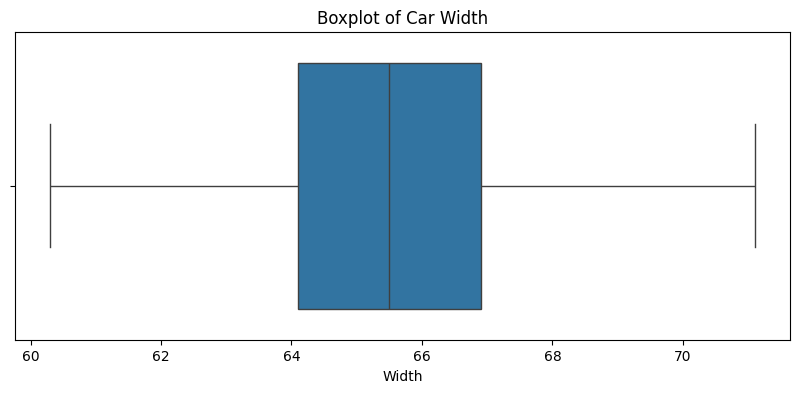

In [110]:
q1,q2,q3 = np.percentile(df['carwidth'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['carwidth']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['carwidth']=np.where(df['carwidth']>upper_limit,upper_limit,df['carwidth'])
df['carwidth']=np.where(df['carwidth']<lower_limit,lower_limit,df['carwidth'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['carwidth'])
plt.title('Boxplot of Car Width')
plt.xlabel('Width')
plt.show()

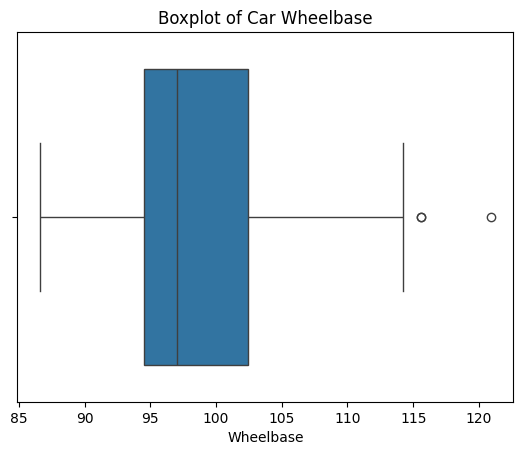

In [111]:
sns.boxplot(x=df['wheelbase'])
plt.title('Boxplot of Car Wheelbase')
plt.xlabel('Wheelbase')
plt.show()

In [112]:
q1,q2,q3 = np.percentile(df['wheelbase'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['wheelbase']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

94.5 97.0 102.4
IQR = 7.900000000000006
Lower Limit 82.64999999999999
Upper Limit 114.25000000000001
[115.6, 115.6, 120.9]


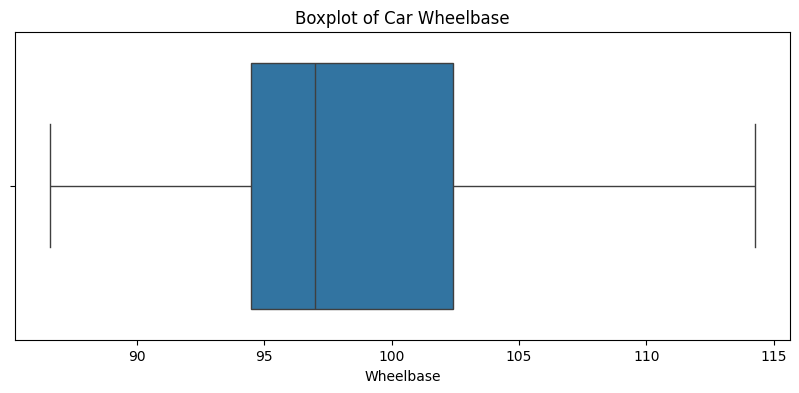

In [113]:
df['wheelbase']=np.where(df['wheelbase']>upper_limit,upper_limit,df['wheelbase'])
df['wheelbase']=np.where(df['wheelbase']<lower_limit,lower_limit,df['wheelbase'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['wheelbase'])
plt.title('Boxplot of Car Wheelbase')
plt.xlabel('Wheelbase')
plt.show()

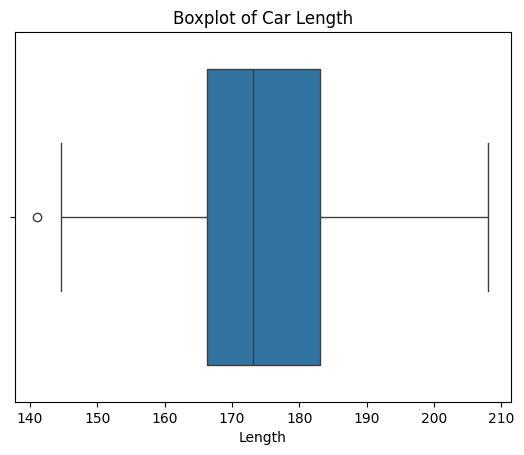

In [114]:
sns.boxplot(x=df['carlength'])
plt.title('Boxplot of Car Length')
plt.xlabel('Length')
plt.show()

166.3 173.2 183.1
IQR = 16.799999999999983
Lower Limit 141.10000000000002
Upper Limit 208.29999999999995
[141.1]


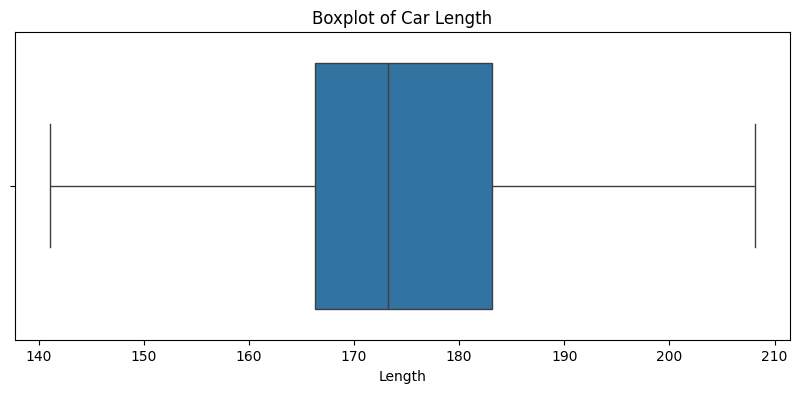

In [115]:
q1,q2,q3 = np.percentile(df['carlength'].dropna(),[25,50,75])
print(q1,q2,q3)
IQR = q3-q1
print("IQR =",IQR)
lower_limit = q1 - 1.5*IQR
upper_limit = q3 + 1.5*IQR
print("Lower Limit",lower_limit)
print("Upper Limit",upper_limit)
outlier =[]
for i in df['carlength']:
  if i<lower_limit or i>upper_limit:
    outlier.append(i)
print(outlier)

df['carlength']=np.where(df['carlength']>upper_limit,upper_limit,df['carlength'])
df['carlength']=np.where(df['carlength']<lower_limit,lower_limit,df['carlength'])


plt.figure(figsize=(10,4))
sns.boxplot(x=df['carlength'])
plt.title('Boxplot of Car Length')
plt.xlabel('Length')
plt.show()

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    float64
 1

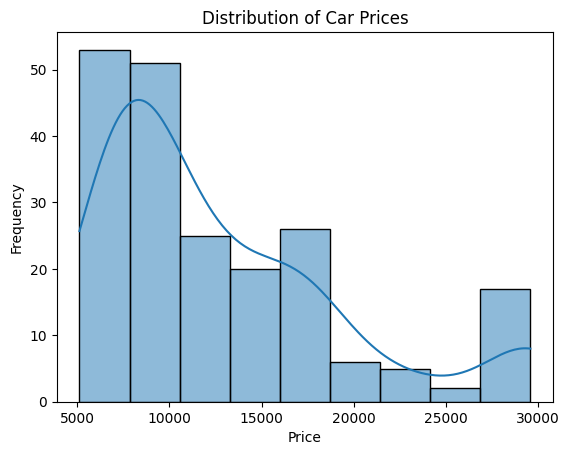

In [117]:
#check whether the price graph is skewwed or not
sns.histplot(df['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

This right skewed. Most people buy between 5000 to 10000. 

ordinary/budget segment dominates. 

There is a bump near 30000 - which says there are two types of groups 
Budget buyers (5k–10k) → large volume
Luxury buyers (27k–30k) → small but significant group

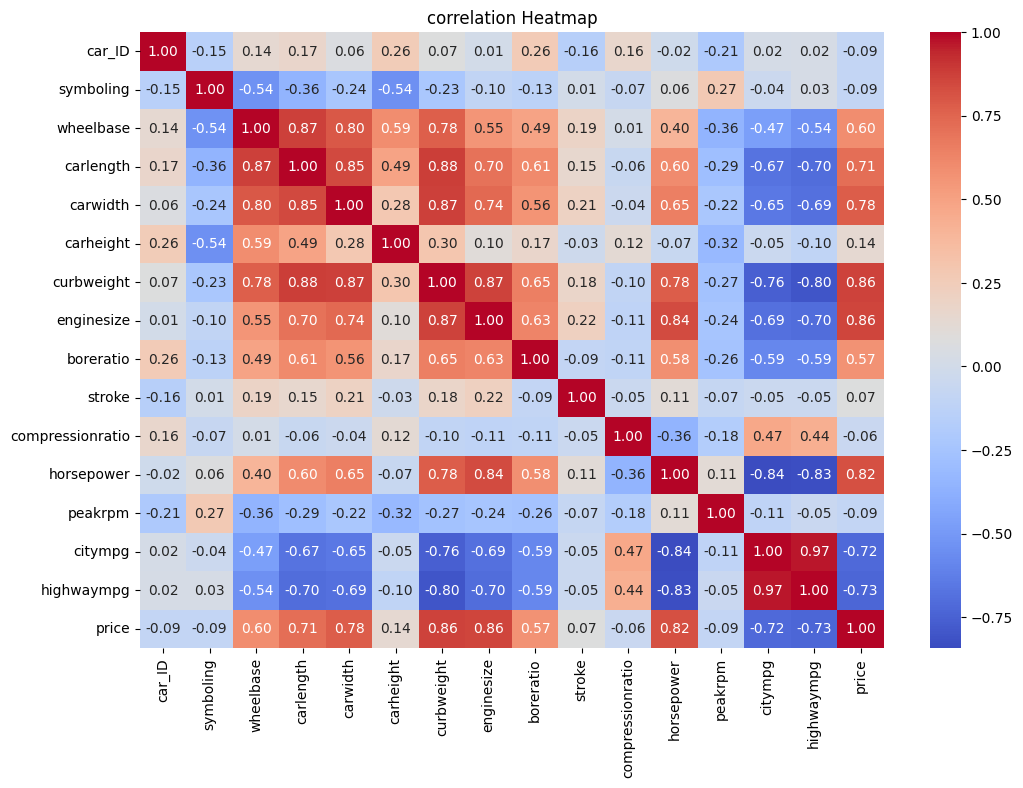

In [118]:
#lets check numerical correlation 
numerical_df= df.select_dtypes(include=['float64','int64'])
correlation=numerical_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('correlation Heatmap')
plt.show()


1. High Positive Correlation with Price

curbweight  0.86    Heavier car = more expensive

enginesize  0.86    Bigger engine = more expensive

horsepower  0.82  More power = more expensive

carwidth    0.78    Wider car = more expensive

carlength   0.71   Longer car = more expensive

wheelbase   0.60    Larger base = more expensive

boreratio   0.57   Moderate relationship

2. peakrpm (-0.09), compressionratio (-0.06), car_ID (-0.09), symboling (-0.09) are near zero. almost NO relationship with price.

Real strong negatives :
citympg (-0.72) 
highwaympg (-0.73) 

More fuel-efficient cars tend to be cheaper.Luxury/powerful cars burn more fuel.

3. Multicollinearity

citympg & highwaympg → 0.97 ← Almost identical, Keep only one

curbweight & enginesize → 0.87

carlength & curbweight → 0.88

carwidth & curbweight → 0.87




In [119]:
#drop columns which are not required for model building
df.drop(['car_ID','symboling', 'citympg'],axis=1,inplace=True)

Why I dropped Citympg?

citympg-> -0.72 and highwaympg-> -0.73. highway is more correlated with price. Since both variables are 0.97 correlated, they carry almost identical information.

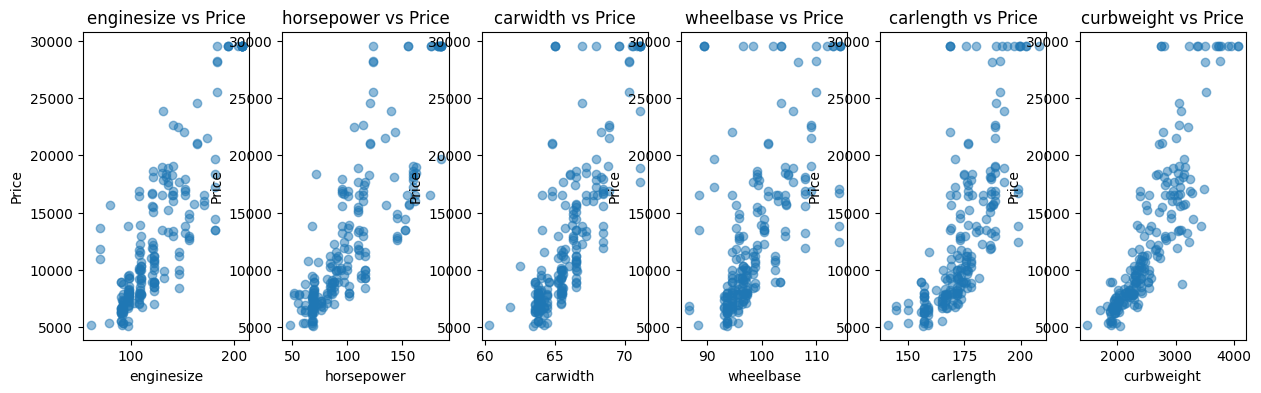

In [120]:
#plot the top features against price
top_features=['enginesize', 'horsepower', 'carwidth', 'wheelbase', 'carlength','curbweight']
fig, axes= plt.subplots(1, 6,figsize=(15,4))
for i, feature in enumerate(top_features):
    axes[i].scatter(df[feature], df['price'], alpha=0.5)
    axes[i].set_title(f'{feature} vs Price')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Price')
plt.show()



BEST features for your model:
 curbweight  → Strong, Linear, No outliers  = IDEAL
 enginesize  → Medium, Linear               = GOOD
 carwidth    → Medium, Linear               = GOOD

WEAKER features:
 wheelbase  → Weak, scattered              = Less useful
 carlength  → Medium, scattered            = Less useful

In [121]:
#Categorical encoding




In [122]:
print(df.select_dtypes(include=['object']).columns.tolist())
print("---")
print(df.select_dtypes(include=['object']).nunique())

['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
---
CarName           147
fueltype            2
aspiration          2
doornumber          2
carbody             5
drivewheel          3
enginelocation      2
enginetype          7
cylindernumber      7
fuelsystem          8
dtype: int64


In [123]:
print(df['CarName'].unique())

['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'audi 5000' 'audi 4000'
 'audi 5000s (diesel)' 'bmw 320i' 'bmw x1' 'bmw x3' 'bmw z4' 'bmw x4'
 'bmw x5' 'chevrolet impala' 'chevrolet monte carlo' 'chevrolet vega 2300'
 'dodge rampage' 'dodge challenger se' 'dodge d200' 'dodge monaco (sw)'
 'dodge colt hardtop' 'dodge colt (sw)' 'dodge coronet custom'
 'dodge dart custom' 'dodge coronet custom (sw)' 'honda civic'
 'honda civic cvcc' 'honda accord cvcc' 'honda accord lx'
 'honda civic 1500 gl' 'honda accord' 'honda civic 1300' 'honda prelude'
 'honda civic (auto)' 'isuzu MU-X' 'isuzu D-Max ' 'isuzu D-Max V-Cross'
 'jaguar xj' 'jaguar xf' 'jaguar xk' 'maxda rx3' 'maxda glc deluxe'
 'mazda rx2 coupe' 'mazda rx-4' 'mazda glc deluxe' 'mazda 626' 'mazda glc'
 'mazda rx-7 gs' 'mazda glc 4' 'mazda glc custom l' 'mazda glc custom'
 'buick electra 225 custom' 'buick century luxus (sw)' 'buick century'
 'buick skyhawk' 'buick opel isuzu 

In [124]:
#extract the brand name from the CarName column
df['brand']=df['CarName'].str.split().str[0]

#convert to lowercase
df['brand']=df['brand'].str.lower()

df['brand'].unique()

df['brand'].value_counts()

brand
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
volkswagen      9
dodge           9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
chevrolet       3
alfa-romero     3
jaguar          3
maxda           2
renault         2
vw              2
porcshce        1
mercury         1
toyouta         1
vokswagen       1
Name: count, dtype: int64

In [125]:
# Fix wrong brand names
df['brand'] = df['brand'].replace({
    'maxda': 'mazda',
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',  
    'toyouta': 'toyota',
    'porcshce': 'porsche'
})

print(df['brand'].value_counts())

brand
toyota         32
nissan         18
mazda          17
mitsubishi     13
honda          13
subaru         12
volkswagen     12
volvo          11
peugeot        11
dodge           9
buick           8
bmw             8
audi            7
plymouth        7
saab            6
porsche         5
isuzu           4
alfa-romero     3
chevrolet       3
jaguar          3
renault         2
mercury         1
Name: count, dtype: int64


In [126]:
# Average price by brand
brand_price = df.groupby('brand')['price'].mean().sort_values(ascending=False)
print(brand_price)

brand
jaguar         29575.500000
buick          28731.687500
porsche        28064.000000
bmw            23590.187500
volvo          18063.181818
audi           17859.166714
mercury        16503.000000
alfa-romero    15498.333333
peugeot        15489.090909
saab           15223.333333
mazda          10652.882353
nissan         10415.666667
volkswagen     10077.500000
toyota          9885.812500
renault         9595.000000
mitsubishi      9239.769231
isuzu           8916.500000
subaru          8541.250000
honda           8184.692308
plymouth        7963.428571
dodge           7875.444444
chevrolet       6007.000000
Name: price, dtype: float64


In [127]:
print(df['fueltype'].unique())
print(df['aspiration'].unique())
print(df['doornumber'].unique())
print(df['carbody'].unique())
print(df['drivewheel'].unique())
print(df['enginetype'].unique())
print(df['cylindernumber'].unique())
print(df['enginelocation'].unique())
print(df['fuelsystem'].unique())

print('\n')
print(df['fueltype'].value_counts())
print(df['aspiration'].value_counts())
print(df['doornumber'].value_counts())
print(df['carbody'].value_counts())
print(df['drivewheel'].value_counts())
print(df['enginetype'].value_counts())
print(df['cylindernumber'].value_counts())
print(df['enginelocation'].value_counts())
print(df['fuelsystem'].value_counts())



['gas' 'diesel']
['std' 'turbo']
['two' 'four']
['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop']
['rwd' 'fwd' '4wd']
['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv']
['four' 'six' 'five' 'three' 'twelve' 'two' 'eight']
['front' 'rear']
['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi']


fueltype
gas       185
diesel     20
Name: count, dtype: int64
aspiration
std      168
turbo     37
Name: count, dtype: int64
doornumber
four    115
two      90
Name: count, dtype: int64
carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64
drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64
enginetype
ohc      148
ohcf      15
ohcv      13
dohc      12
l         12
rotor      4
dohcv      1
Name: count, dtype: int64
cylindernumber
four      159
six        24
five       11
eight       5
two         4
twelve      1
three       1
Name: count, dtype: int64
enginelocation
front    202
rear       3
Name: count,

In [128]:
fuel_price = df.groupby('fueltype')['price'].mean().sort_values(ascending=False)
print(fuel_price)
print('\n')
aspiration_price = df.groupby('aspiration')['price'].mean().sort_values(ascending=False)
print(aspiration_price)
print('\n')
doornumber_price = df.groupby('doornumber')['price'].mean().sort_values(ascending=False)
print(doornumber_price)
print('\n')
carbody_price = df.groupby('carbody')['price'].mean().sort_values(ascending=False)
print(carbody_price)
print('\n')




fueltype
diesel    15736.925000
gas       12517.190092
Name: price, dtype: float64


aspiration
turbo    16243.450459
std      12079.827381
Name: price, dtype: float64


doornumber
four    13195.452174
two     12366.018522
Name: price, dtype: float64


carbody
convertible    19735.000000
hardtop        19304.812500
sedan          13788.859375
wagon          12371.960000
hatchback      10350.580957
Name: price, dtype: float64




In [129]:
drivewheel_price = df.groupby('drivewheel')['price'].mean().sort_values(ascending=False )
print(drivewheel_price) 
print('\n')
enginetype_price = df.groupby('enginetype')['price'].mean().sort_values(ascending=False)
print(enginetype_price)
print('\n')
cylindernumber_price = df.groupby('cylindernumber')['price'].mean().sort_values(ascending=False)
print(cylindernumber_price) 
print('\n')



drivewheel
rwd    18709.401316
4wd    11087.463000
fwd     9239.308333
Name: price, dtype: float64


enginetype
dohcv    29575.500000
ohcv     21735.115385
dohc     17395.666667
l        14627.583333
rotor    13020.000000
ohcf     12748.100000
ohc      11423.690318
Name: price, dtype: float64


cylindernumber
eight     29575.500000
twelve    29575.500000
six       21849.541667
five      21446.424273
two       13020.000000
four      10285.754717
three      5151.000000
Name: price, dtype: float64




In [130]:
enginelocation_price = df.groupby('enginelocation')['price'].mean().sort_values(ascending=False)
print(enginelocation_price)
print('\n')
fuelsystem_price = df.groupby('fuelsystem')['price'].mean().sort_values(ascending=False)
print(fuelsystem_price) 

enginelocation
rear     29575.50000
front    12582.63449
Name: price, dtype: float64


fuelsystem
mpfi    16804.789011
idi     15736.925000
mfi     12964.000000
4bbl    12145.000000
spfi    11048.000000
spdi    10990.444444
1bbl     7555.545455
2bbl     7478.151515
Name: price, dtype: float64


In [131]:
df.drop('doornumber', axis=1, inplace=True)

In [132]:
cylinder_order = {'two':2, 'three':3, 'four':4,
                  'five':5, 'six':6, 'eight':8, 'twelve':12}
df['cylindernumber'] = df['cylindernumber'].map(cylinder_order)

In [133]:
categorical_cols = ['fueltype', 'aspiration', 'carbody', 
                    'drivewheel', 'enginelocation', 'enginetype',
                    'fuelsystem', 'brand']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df.shape)
print(df.head())

(205, 58)
                    CarName  wheelbase  carlength  carwidth  carheight  \
0        alfa-romero giulia       88.6      168.8      64.1       48.8   
1       alfa-romero stelvio       88.6      168.8      64.1       48.8   
2  alfa-romero Quadrifoglio       94.5      171.2      65.5       52.4   
3               audi 100 ls       99.8      176.6      66.2       54.3   
4                audi 100ls       99.4      176.6      66.4       54.3   

   curbweight  cylindernumber  enginesize  boreratio  stroke  ...  \
0        2548               4       130.0       3.47    2.68  ...   
1        2548               4       130.0       3.47    2.68  ...   
2        2823               6       152.0       2.68    3.47  ...   
3        2337               4       109.0       3.19    3.40  ...   
4        2824               5       136.0       3.19    3.40  ...   

   brand_nissan  brand_peugeot  brand_plymouth  brand_porsche  brand_renault  \
0         False          False           False    

In [134]:
print(df.dtypes.value_counts())

bool       43
float64    12
int64       2
object      1
Name: count, dtype: int64


In [135]:
print(df.select_dtypes(include=['object']).columns.tolist())

['CarName']


In [136]:

df.drop('CarName', axis=1, inplace=True)

print(df.shape)
print(df.dtypes.value_counts())

(205, 57)
bool       43
float64    12
int64       2
Name: count, dtype: int64


In [137]:
# Convert bool columns to integers
df = df.astype({col: int for col in df.select_dtypes(include='bool').columns})
print(df.dtypes.value_counts())
print(df.shape)

int64      45
float64    12
Name: count, dtype: int64
(205, 57)


In [138]:
# Check 1: Any nulls?
print("Null values:", df.isnull().sum().sum())

# Check 2: Shape
print("Shape:", df.shape)

# Check 3: All numeric?
print(df.dtypes.value_counts())

Null values: 0
Shape: (205, 57)
int64      45
float64    12
Name: count, dtype: int64


In [139]:
y = df['price']
X = df.drop('price', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (205, 56)
y shape: (205,)


In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (164, 56)
X_test shape: (41, 56)
y_train shape: (164,)
y_test shape: (41,)


In [144]:
#Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
# Transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  
# ↑ Notice: transform only, NOT fit_transform!

print("X_train scaled shape:", X_train_scaled.shape)
print("X_test scaled shape:", X_test_scaled.shape)

X_train scaled shape: (164, 56)
X_test scaled shape: (41, 56)


In [145]:
#model building 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Define all 5 models
models = {
    'Linear Regression'    : LinearRegression(),
    'Decision Tree'        : DecisionTreeRegressor(random_state=42),
    'Random Forest'        : RandomForestRegressor(random_state=42),
    'Gradient Boosting'    : GradientBoostingRegressor(random_state=42),
    'SVR'                  : SVR()
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Metrics
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name, 
        'MAE'  : round(mae, 2), 
        'RMSE' : round(rmse, 2), 
        'R2'   : round(r2, 4)
    })


results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print(results_df.to_string(index=False))

            Model     MAE    RMSE      R2
Gradient Boosting 1050.68 1396.63  0.9632
    Random Forest 1056.04 1491.11  0.9580
    Decision Tree 1160.58 1722.07  0.9440
Linear Regression 1469.99 2058.77  0.9200
              SVR 5114.24 7615.59 -0.0951




the correct order is split first then scale x train only then apply same scale to x test

decision tree, random forest, gradient boosting do need scaling, they are tree based and scale independent.

Gradient boosting is the best model and SVM is worst model 

In [146]:
#checking the overfitting on best models
best_models = ['Gradient Boosting', 
               'Random Forest', 
               'Decision Tree']

for name in best_models:
    model    = models[name]
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2  = r2_score(y_test, model.predict(X_test))
    gap      = train_r2 - test_r2
    
    print(f"{name}")
    print(f"  Train R² : {train_r2:.4f}")
    print(f"  Test  R² : {test_r2:.4f}")
    print(f"  Gap      : {gap:.4f}")
    print("-" * 40)

Gradient Boosting
  Train R² : 0.9921
  Test  R² : 0.9632
  Gap      : 0.0289
----------------------------------------
Random Forest
  Train R² : 0.9856
  Test  R² : 0.9580
  Gap      : 0.0276
----------------------------------------
Decision Tree
  Train R² : 0.9990
  Test  R² : 0.9440
  Gap      : 0.0550
----------------------------------------


HYPERPARAMETER TUNING

In [ ]:
'''from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Hyperparameter grid
gb_params = {
    'n_estimators': [200, 300, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# Base model
gb_model = GradientBoostingRegressor(random_state=42)

# Grid Search
gb_grid = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_params,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit
gb_grid.fit(X_train, y_train)

# Best model
gb_best = gb_grid.best_estimator_

# Evaluate tuned model
y_pred_gb = gb_best.predict(X_test)

gb_mae  = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2   = r2_score(y_test, y_pred_gb)

print("Best Hyperparameters:", gb_grid.best_params_)
print(f"Tuned Gradient Boosting MAE : {gb_mae:.2f}")
print(f"Tuned Gradient Boosting RMSE: {gb_rmse:.2f}")
print(f"Tuned Gradient Boosting R²  : {gb_r2:.4f}")'''



Best Hyperparameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
Tuned Gradient Boosting MAE : 1043.31
Tuned Gradient Boosting RMSE: 1439.56
Tuned Gradient Boosting R²  : 0.9609


There no much difference after tuning , MAE has reduced. 

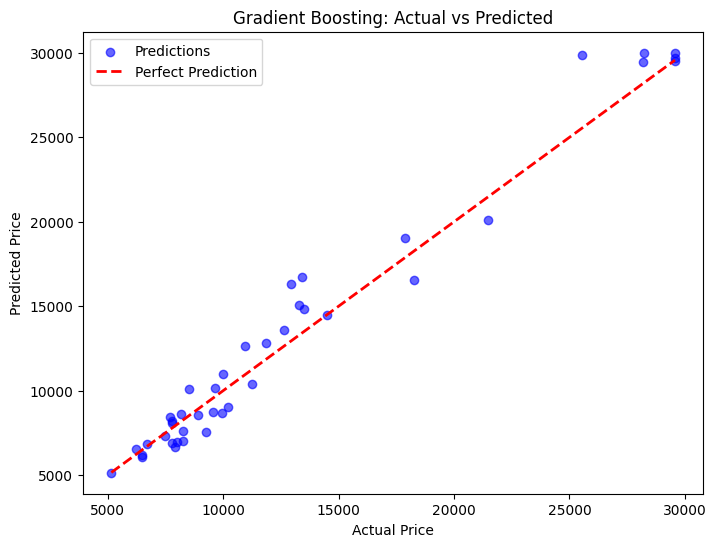

In [147]:
gb_model  = models['Gradient Boosting']
y_pred_gb = gb_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_gb, 
            alpha=0.6, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Gradient Boosting: Actual vs Predicted')
plt.legend()
plt.show()

           Feature  Importance
4       curbweight    0.506411
6       enginesize    0.218932
12      highwaympg    0.092429
10      horsepower    0.062130
5   cylindernumber    0.024780
1        carlength    0.018707
2         carwidth    0.015206
0        wheelbase    0.013870
36       brand_bmw    0.009936
8           stroke    0.007787


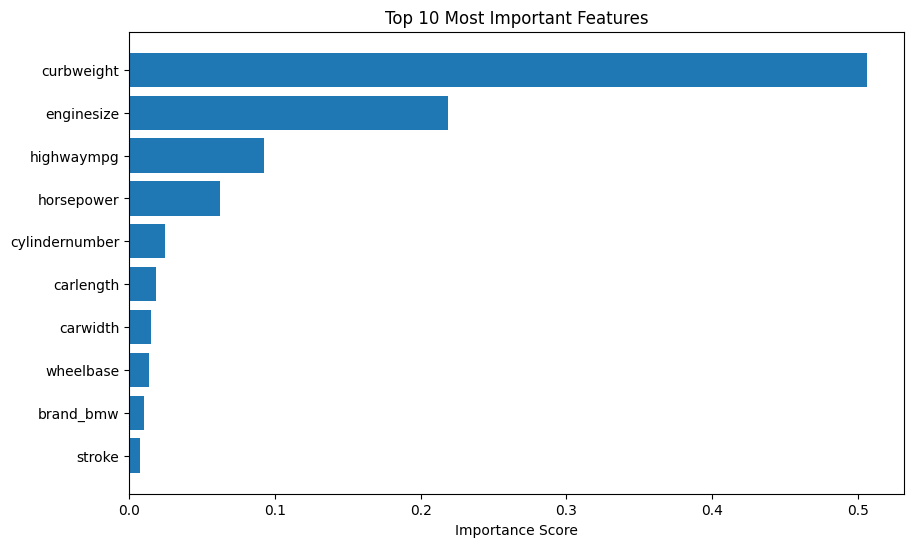

In [148]:
# Which features matter most to YOUR best model?
gb_model     = models['Gradient Boosting']
importances  = gb_model.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

print(importance_df)

# Plot it
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], 
         importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.show()

In [152]:
print("=" * 50)
print("   CAR PRICE PREDICTION - FINAL SUMMARY")
print("=" * 50)
print(f"\nDataset    : 205 cars, 57 features")
print(f"Best Model : Gradient Boosting")
print(f"R² Score   : 0.9632 (explains 96% of price variation)")
print(f"MAE        : $1,050 average error")
print(f"\nTop 3 Price Predictors:")
print(f"  1. curbweight  (50.6% importance)")
print(f"  2. enginesize  (21.9% importance)")
print(f"  3. highwaympg  ( 9.2% importance)")
print(f"\nModel Status: No overfitting detected ")

   CAR PRICE PREDICTION - FINAL SUMMARY

Dataset    : 205 cars, 57 features
Best Model : Gradient Boosting
R² Score   : 0.9632 (explains 96% of price variation)
MAE        : $1,050 average error

Top 3 Price Predictors:
  1. curbweight  (50.6% importance)
  2. enginesize  (21.9% importance)
  3. highwaympg  ( 9.2% importance)

Model Status: No overfitting detected 


Business Insights:

1. Focus on car weight and engine size.
2. fuel efficency is important
3. invest in engineering quality not just brand marketing